In [1]:
import pandas as pd

In [2]:


sales1 = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Sales Data 2020.csv")
sales2 = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Sales Data 2021.csv")
sales3 = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Sales Data 2022.csv")







In [3]:

sales = pd.concat([sales1,sales2,sales3],ignore_index=True)


In [4]:


print("Sales rows combined:", len(sales))


display(sales.head())


Sales rows combined: 56046


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1


In [19]:

customers     = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Customer.csv")
subcats      = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Product Subcategories.csv")
cats         =pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Product Categories.csv")
products    =pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Product.csv")
returns      =pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Returns Data.csv")


In [6]:
print("\nProducts rows:", len(products))
print("Subcategories rows:", len(subcats))
print("Categories rows:", len(cats))
print("Customers rows:", len(customers))
print("Returns rows:", len(returns))

print("\n--- Data Loaded Successfully ---")

print(sales.dtypes)



Products rows: 18148
Subcategories rows: 37
Categories rows: 4
Customers rows: 293
Returns rows: 1809

--- Data Loaded Successfully ---
OrderDate        object
StockDate        object
OrderNumber      object
ProductKey        int64
CustomerKey       int64
TerritoryKey      int64
OrderLineItem     int64
OrderQuantity     int64
dtype: object


In [7]:
sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])
sales

sales.dtypes

OrderDate        datetime64[ns]
StockDate                object
OrderNumber              object
ProductKey                int64
CustomerKey               int64
TerritoryKey              int64
OrderLineItem             int64
OrderQuantity             int64
dtype: object

In [15]:
sales['StockDate'] = pd.to_datetime(sales['StockDate'])
returns['ReturnDate'] = pd.to_datetime(returns['ReturnDate'])


In [20]:
customers['BirthDate'] = pd.to_datetime(customers['BirthDate'], dayfirst=True, errors='coerce')

In [21]:
customers.columns

Index(['CustomerKey', 'Prefix', 'FirstName', 'LastName', 'BirthDate',
       'MaritalStatus', 'Gender', 'EmailAddress', 'AnnualIncome',
       'TotalChildren', 'EducationLevel', 'Occupation', 'HomeOwner'],
      dtype='object')

In [22]:
print(sales.dtypes)
print(returns.dtypes)

OrderDate        datetime64[ns]
StockDate        datetime64[ns]
OrderNumber              object
ProductKey                int64
CustomerKey               int64
TerritoryKey              int64
OrderLineItem             int64
OrderQuantity             int64
dtype: object
ReturnDate        object
TerritoryKey       int64
ProductKey         int64
ReturnQuantity     int64
dtype: object


In [23]:
# Phase 2: Basic EDA (very simple inspections)

# 1. Check the shape (rows, columns)
print("Sales shape (rows, columns):", sales.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Returns shape:", returns.shape)

# 2. Look at column names
print("\nSales columns:")
print(sales.columns.tolist())

# 3. Look at top 5 rows — quick data feel
print("\nSales - first 5 rows:")
display(sales.head())

# 4. Check data types (important for dates & numbers)
print("\nSales dtypes:")
print(sales.dtypes)

# 5. Check missing values (just counts)
print("\nMissing values in Sales:")
print(sales.isna().sum())

# 6. Quick numerical summary (mean, min, max)
print("\nBasic statistics (numeric columns):")
print(sales.describe().round(2))


Sales shape (rows, columns): (56046, 8)
Products shape: (293, 11)
Customers shape: (18148, 13)
Returns shape: (1809, 4)

Sales columns:
['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey', 'TerritoryKey', 'OrderLineItem', 'OrderQuantity']

Sales - first 5 rows:


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1



Sales dtypes:
OrderDate        datetime64[ns]
StockDate        datetime64[ns]
OrderNumber              object
ProductKey                int64
CustomerKey               int64
TerritoryKey              int64
OrderLineItem             int64
OrderQuantity             int64
dtype: object

Missing values in Sales:
OrderDate        0
StockDate        0
OrderNumber      0
ProductKey       0
CustomerKey      0
TerritoryKey     0
OrderLineItem    0
OrderQuantity    0
dtype: int64

Basic statistics (numeric columns):
       ProductKey  CustomerKey  TerritoryKey  OrderLineItem  OrderQuantity
count    56046.00     56046.00      56046.00       56046.00       56046.00
mean       438.96     18843.65          6.25           1.90           1.50
std        118.61      5412.45          2.96           1.02           0.61
min        214.00     11000.00          1.00           1.00           1.00
25%        360.00     14016.00          4.00           1.00           1.00
50%        479.00     18157.00       

In [24]:
sales

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1
...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2


In [25]:
# 1) Join product info to sales (LEFT join so we do not lose sales rows)
sales = sales.merge(
    products[['ProductKey','ProductName','ProductPrice','ProductCost','ProductSubcategoryKey']],
    how='left',
    on='ProductKey'
)
print(sales.columns)
sales

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey'],
      dtype='object')


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,ProductCost,ProductSubcategoryKey
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.0982,413.1463,2
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.9900,1898.0944,1
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.0982,413.1463,2
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2
...,...,...,...,...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.9900,1.8663,28
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.9900,3.3623,28
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1,"Road-750 Black, 52",539.9900,343.6496,2
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2,Patch Kit/8 Patches,2.2900,0.8565,37


In [26]:
sales = sales.merge(
    subcats[['ProductSubcategoryKey','SubcategoryName','ProductCategoryKey']],
    how='left',
    on='ProductSubcategoryKey'
)

In [27]:
sales = sales.merge(
    cats[['ProductCategoryKey','CategoryName']],
    how='left',
    on='ProductCategoryKey'
)

In [28]:
sales

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,ProductCost,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey,CategoryName
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.0982,413.1463,2,Road Bikes,1,Bikes
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.9900,1898.0944,1,Mountain Bikes,1,Bikes
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.0982,413.1463,2,Road Bikes,1,Bikes
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.9900,1.8663,28,Bottles and Cages,4,Accessories
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.9900,3.3623,28,Bottles and Cages,4,Accessories
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1,"Road-750 Black, 52",539.9900,343.6496,2,Road Bikes,1,Bikes
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2,Patch Kit/8 Patches,2.2900,0.8565,37,Tires and Tubes,4,Accessories


In [29]:
sales = sales.merge(
    customers[['CustomerKey','FirstName','LastName','Gender','AnnualIncome']],
    how='left',
    on='CustomerKey'
)

In [30]:
sales

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,ProductCost,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey,CategoryName,FirstName,LastName,Gender,AnnualIncome
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.0982,413.1463,2,Road Bikes,1,Bikes,JOHN,THOMAS,M,80000
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes,KYLE,WASHINGTON,M,80000
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.9900,1898.0944,1,Mountain Bikes,1,Bikes,ROSS,SANZ,M,100000
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.0982,413.1463,2,Road Bikes,1,Bikes,SETH,LEWIS,M,30000
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes,ALEJANDRO,CHEN,M,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.9900,1.8663,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.9900,3.3623,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1,"Road-750 Black, 52",539.9900,343.6496,2,Road Bikes,1,Bikes,TROY,GONZALEZ,M,20000
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2,Patch Kit/8 Patches,2.2900,0.8565,37,Tires and Tubes,4,Accessories,VALERIE,GUO,F,20000


In [31]:
len(sales.columns)

19

In [32]:
# 5) Replace any missing text fields with 'Unknown' so tables/plots don't break
text_cols = ['ProductName','SubcategoryName','CategoryName','FirstName','LastName','Gender']
for c in text_cols:
    if c in sales.columns:
        sales[c] = sales[c].fillna('Unknown')

In [34]:
sales[sales["Gender"]=="M"]

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,ProductCost,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey,CategoryName,FirstName,LastName,Gender,AnnualIncome
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.0982,413.1463,2,Road Bikes,1,Bikes,JOHN,THOMAS,M,80000
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes,KYLE,WASHINGTON,M,80000
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.9900,1898.0944,1,Mountain Bikes,1,Bikes,ROSS,SANZ,M,100000
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.0982,413.1463,2,Road Bikes,1,Bikes,SETH,LEWIS,M,30000
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.2700,2171.2942,2,Road Bikes,1,Bikes,ALEJANDRO,CHEN,M,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56039,2022-06-30,2022-03-28,SO74105,229,20223,9,4,1,"Long-Sleeve Logo Jersey, M",48.0673,31.7244,21,Jerseys,3,Clothing,TERRANCE,MALHOTRA,M,70000
56040,2022-06-30,2022-06-02,SO74143,462,28517,10,4,2,"Half-Finger Gloves, S",23.5481,9.7136,20,Gloves,3,Clothing,TROY,GONZALEZ,M,20000
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.9900,1.8663,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.9900,3.3623,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000


In [35]:
sales[sales["Gender"]=="Gender"]

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,ProductCost,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey,CategoryName,FirstName,LastName,Gender,AnnualIncome


In [36]:
sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName', 'FirstName',
       'LastName', 'Gender', 'AnnualIncome'],
      dtype='object')

In [37]:
# 6) Create Revenue
sales['Revenue'] = sales['OrderQuantity'] * sales['ProductPrice']
sales['Profit']  = sales['OrderQuantity'] * (sales['ProductPrice'] - sales['ProductCost'])


In [38]:
sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName', 'FirstName',
       'LastName', 'Gender', 'AnnualIncome', 'Revenue', 'Profit'],
      dtype='object')

In [39]:
sales[["Revenue","Profit"]]

,Revenue,Profit
0,699.0982,285.9519
1,3578.2700,1406.9758
2,3374.9900,1476.8956
3,699.0982,285.9519
4,3578.2700,1406.9758
...,...,...
56041,9.9800,6.2474
56042,8.9900,5.6277
56043,539.9900,196.3404
56044,4.5800,2.8670


In [40]:
# 7) Quick checks to confirm joins
print("Rows in sales after joins:", len(sales))
print("Count of sales rows with missing ProductName:", sales['ProductName'].isna().sum())
print("Count of sales rows with missing Customer info (FirstName):", (sales['FirstName']=='Unknown').sum())

Rows in sales after joins: 56046
Count of sales rows with missing ProductName: 0
Count of sales rows with missing Customer info (FirstName): 0


In [41]:
# 8) Show small samples and summary
print("\nSample rows with revenue/profit:")
display(sales[['OrderNumber','OrderDate','ProductKey','ProductName','OrderQuantity','ProductPrice','Revenue','Profit']].head(8))


Sample rows with revenue/profit:


,OrderNumber,OrderDate,ProductKey,ProductName,OrderQuantity,ProductPrice,Revenue,Profit
0,SO45080,2020-01-01,332,"Road-650 Black, 58",1,699.0982,699.0982,285.9519
1,SO45079,2020-01-01,312,"Road-150 Red, 48",1,3578.2700,3578.2700,1406.9758
2,SO45082,2020-01-01,350,"Mountain-100 Black, 44",1,3374.9900,3374.9900,1476.8956
3,SO45081,2020-01-01,338,"Road-650 Black, 44",1,699.0982,699.0982,285.9519
4,SO45083,2020-01-02,312,"Road-150 Red, 48",1,3578.2700,3578.2700,1406.9758
5,SO45084,2020-01-02,310,"Road-150 Red, 62",1,3578.2700,3578.2700,1406.9758
6,SO45086,2020-01-02,314,"Road-150 Red, 56",1,3578.2700,3578.2700,1406.9758
7,SO45085,2020-01-02,312,"Road-150 Red, 48",1,3578.2700,3578.2700,1406.9758


In [42]:
print("\nTop 5 Product Categories by Revenue:")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
cat_rev = sales.groupby('CategoryName', dropna=False)['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
display(cat_rev.head(5))


Top 5 Product Categories by Revenue:


,CategoryName,Revenue
1,Bikes,23642495.10
0,Accessories,906673.11
2,Clothing,365418.62


In [43]:
print("\nTop 10 Products by Revenue:")
prod_rev = sales.groupby(['CategoryName','ProductName'])['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False).head(10)
display(prod_rev)


Top 10 Products by Revenue:


,CategoryName,ProductName,Revenue
32,Bikes,"Mountain-200 Black, 46",1241753.51
31,Bikes,"Mountain-200 Black, 42",1233557.12
33,Bikes,"Mountain-200 Silver, 38",1213851.89
35,Bikes,"Mountain-200 Silver, 46",1182780.59
30,Bikes,"Mountain-200 Black, 38",1165936.88
34,Bikes,"Mountain-200 Silver, 42",1133066.52
57,Bikes,"Road-250 Black, 52",689373.75
62,Bikes,"Road-250 Red, 58",661013.44
56,Bikes,"Road-250 Black, 48",641379.38
51,Bikes,"Road-150 Red, 48",640510.33


In [44]:
sales.groupby('ProductKey')['OrderQuantity'].sum().reset_index().rename(columns={'OrderQuantity':'SoldQty'})


,ProductKey,SoldQty
0,214,2099
1,215,1940
2,220,1995
3,223,4151
4,226,392
...,...,...
125,599,55
126,600,41
127,604,356
128,605,355


In [45]:
# 9) Simple Returns join to compute return rate by product (very basic)
# Aggregate sold qty by product
sold_by_product = sales.groupby('ProductKey')['OrderQuantity'].sum().reset_index().rename(columns={'OrderQuantity':'SoldQty'})

In [46]:
sold_by_product

,ProductKey,SoldQty
0,214,2099
1,215,1940
2,220,1995
3,223,4151
4,226,392
...,...,...
125,599,55
126,600,41
127,604,356
128,605,355


In [47]:
# Aggregate returns by product (from returns DF)
returns_by_product = returns.groupby('ProductKey')['ReturnQuantity'].sum().reset_index().rename(columns={'ReturnQuantity':'ReturnQty'})

In [48]:
returns_by_product

,ProductKey,ReturnQty
0,214,70
1,215,52
2,220,66
3,223,46
4,226,12
...,...,...
119,599,1
120,600,3
121,604,7
122,605,15


In [49]:
# Merge and compute return rate
returns_summary = sold_by_product.merge(returns_by_product, how='left', on='ProductKey')
returns_summary['ReturnQty'] = returns_summary['ReturnQty'].fillna(0)
returns_summary['ReturnRate'] = returns_summary['ReturnQty'] / returns_summary['SoldQty']

In [50]:
returns_summary

,ProductKey,SoldQty,ReturnQty,ReturnRate
0,214,2099,70.00,0.03
1,215,1940,52.00,0.03
2,220,1995,66.00,0.03
3,223,4151,46.00,0.01
4,226,392,12.00,0.03
...,...,...,...,...
125,599,55,1.00,0.02
126,600,41,3.00,0.07
127,604,356,7.00,0.02
128,605,355,15.00,0.04


In [52]:
print("\nTop products by return rate (only products with sold qty > 0):")
display(returns_summary[returns_summary['SoldQty']>0].sort_values('ReturnRate', ascending=False).head(8))


Top products by return rate (only products with sold qty > 0):


,ProductKey,SoldQty,ReturnQty,ReturnRate
18,330,51,6.00,0.12
27,346,24,2.00,0.08
103,577,96,8.00,0.08
126,600,41,3.00,0.07
31,350,31,2.00,0.06
91,565,54,3.00,0.06
32,351,36,2.00,0.06
17,328,75,4.00,0.05


In [53]:
# End of Phase 3
print("\nPhase 3 complete — joins, Revenue/Profit, basic product/category and returns summaries are ready.")


Phase 3 complete — joins, Revenue/Profit, basic product/category and returns summaries are ready.


KPIs

In [54]:
total_sales = sales['Revenue'].sum()
total_orders = sales['OrderNumber'].nunique()
total_qty = sales['OrderQuantity'].sum()

In [55]:
avg_order_value = total_sales / total_orders if total_orders > 0 else 0


In [56]:
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_qty)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 24914586.82
Total Orders: 25164
Total Quantity Sold: 84174
Average Order Value: 990.09


In [57]:
# ---- 2. Monthly sales trend (only rows where OrderDate exists) ----
# dropna() so we only use valid dates
monthly_data = sales.dropna(subset=['OrderDate'])

In [58]:
monthly_data

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,...,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey,CategoryName,FirstName,LastName,Gender,AnnualIncome,Revenue,Profit
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.10,...,2,Road Bikes,1,Bikes,JOHN,THOMAS,M,80000,699.10,285.95
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.27,...,2,Road Bikes,1,Bikes,KYLE,WASHINGTON,M,80000,3578.27,1406.98
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.99,...,1,Mountain Bikes,1,Bikes,ROSS,SANZ,M,100000,3374.99,1476.90
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.10,...,2,Road Bikes,1,Bikes,SETH,LEWIS,M,30000,699.10,285.95
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.27,...,2,Road Bikes,1,Bikes,ALEJANDRO,CHEN,M,20000,3578.27,1406.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.99,...,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000,9.98,6.25
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.99,...,28,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000,8.99,5.63
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1,"Road-750 Black, 52",539.99,...,2,Road Bikes,1,Bikes,TROY,GONZALEZ,M,20000,539.99,196.34
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2,Patch Kit/8 Patches,2.29,...,37,Tires and Tubes,4,Accessories,VALERIE,GUO,F,20000,4.58,2.87


In [59]:
# create Year-Month column
monthly_data['YearMonth'] = monthly_data['OrderDate'].dt.to_period('M')
monthly_data

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductName,ProductPrice,...,SubcategoryName,ProductCategoryKey,CategoryName,FirstName,LastName,Gender,AnnualIncome,Revenue,Profit,YearMonth
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,"Road-650 Black, 58",699.10,...,Road Bikes,1,Bikes,JOHN,THOMAS,M,80000,699.10,285.95,2020-01
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,"Road-150 Red, 48",3578.27,...,Road Bikes,1,Bikes,KYLE,WASHINGTON,M,80000,3578.27,1406.98,2020-01
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,"Mountain-100 Black, 44",3374.99,...,Mountain Bikes,1,Bikes,ROSS,SANZ,M,100000,3374.99,1476.90,2020-01
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,"Road-650 Black, 44",699.10,...,Road Bikes,1,Bikes,SETH,LEWIS,M,30000,699.10,285.95,2020-01
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,"Road-150 Red, 48",3578.27,...,Road Bikes,1,Bikes,ALEJANDRO,CHEN,M,20000,3578.27,1406.98,2020-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56041,2022-06-30,2022-03-22,SO74143,477,28517,10,3,2,Water Bottle - 30 oz.,4.99,...,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000,9.98,6.25,2022-06
56042,2022-06-30,2022-03-15,SO74143,479,28517,10,2,1,Road Bottle Cage,8.99,...,Bottles and Cages,4,Accessories,TROY,GONZALEZ,M,20000,8.99,5.63,2022-06
56043,2022-06-30,2022-04-08,SO74143,606,28517,10,1,1,"Road-750 Black, 52",539.99,...,Road Bikes,1,Bikes,TROY,GONZALEZ,M,20000,539.99,196.34,2022-06
56044,2022-06-30,2022-05-15,SO74124,480,21676,7,2,2,Patch Kit/8 Patches,2.29,...,Tires and Tubes,4,Accessories,VALERIE,GUO,F,20000,4.58,2.87,2022-06


In [60]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
monthly_sales = monthly_data.groupby('YearMonth')['Revenue'].sum().reset_index()

In [61]:
print("\nMonthly Sales (Year-Month):")
display(monthly_sales.head(10))


Monthly Sales (Year-Month):


,YearMonth,Revenue
0,2020-01,585312.65
1,2020-02,532226.25
2,2020-03,643436.10
3,2020-04,653364.04
4,2020-05,659325.90
5,2020-06,669988.67
6,2020-07,486115.01
7,2020-08,536452.82
8,2020-09,344062.87
9,2020-10,404276.60


In [62]:
# ---- 3. Top 10 products by revenue ----
product_sales = sales.groupby(['ProductKey','ProductName'])['Revenue'].sum().reset_index()
product_sales = product_sales.sort_values('Revenue', ascending=False).head(10)
print("\nTop 10 Products by Revenue:")
display(product_sales)


Top 10 Products by Revenue:


,ProductKey,ProductName,Revenue
38,362,"Mountain-200 Black, 46",1241753.51
37,360,"Mountain-200 Black, 42",1233557.12
33,352,"Mountain-200 Silver, 38",1213851.89
35,356,"Mountain-200 Silver, 46",1182780.59
36,358,"Mountain-200 Black, 38",1165936.88
34,354,"Mountain-200 Silver, 42",1133066.52
45,377,"Road-250 Black, 52",689373.75
42,371,"Road-250 Red, 58",661013.44
44,375,"Road-250 Black, 48",641379.38
10,312,"Road-150 Red, 48",640510.33


In [63]:
# ---- 4. Category-wise revenue ----
category_sales = sales.groupby('CategoryName', dropna=False)['Revenue'].sum().reset_index()
category_sales = category_sales.sort_values('Revenue', ascending=False)

In [64]:
print("\nCategory Revenue:")
display(category_sales)


Category Revenue:


,CategoryName,Revenue
1,Bikes,23642495.10
0,Accessories,906673.11
2,Clothing,365418.62


KPIS  Texts



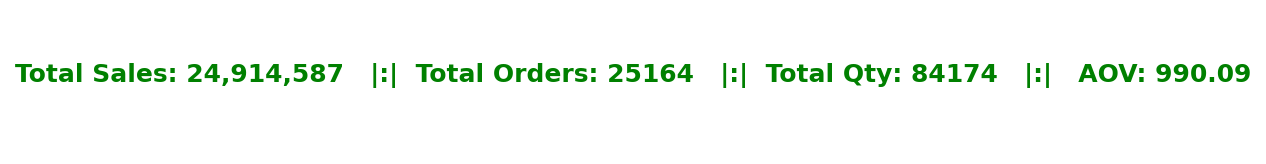

In [67]:
import matplotlib.pyplot as plt # Makes your charts sharper and clearer.
plt.rcParams.update({'figure.dpi':150})
fig, ax = plt.subplots(figsize=(8,1.2))
ax.axis('off') # turns off the grid
txt = f"Total Sales: {total_sales:,.0f}   |:|  Total Orders: {total_orders}   |:|  Total Qty: {total_qty}   |:|   AOV: {avg_order_value:,.2f}"
ax.text(0,0.5, txt, fontsize=12,color="Green",fontweight='bold')
plt.tight_layout() # makes sure your chart elements don’t get cut off.
plt.savefig('KPI')
plt.show()


CHART02  Monthly____Trends

In [68]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()


In [69]:
monthly_sales = monthly_data.groupby('YearMonth')['Revenue'].sum().reset_index()

In [70]:
monthly_sales

,YearMonth,Revenue
0,2020-01,585312.65
1,2020-02,532226.25
2,2020-03,643436.10
3,2020-04,653364.04
4,2020-05,659325.90
5,2020-06,669988.67
6,2020-07,486115.01
7,2020-08,536452.82
8,2020-09,344062.87
9,2020-10,404276.60


In [71]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

In [76]:
monthly_sales.dtypes

YearMonth    datetime64[ns]
Revenue             float64
dtype: object

In [77]:
import seaborn as sns

"plt.gca() → get current axes (the graph you just plotted)\n\n.yaxis → access the Y-axis\n\n.set_major_formatter(...) → control how tick labels are shown\n\nStrMethodFormatter('{x:,.2f}') →\nformat each Y value:\n\n, → thousand separator\n\n.2f → 2 decimals"

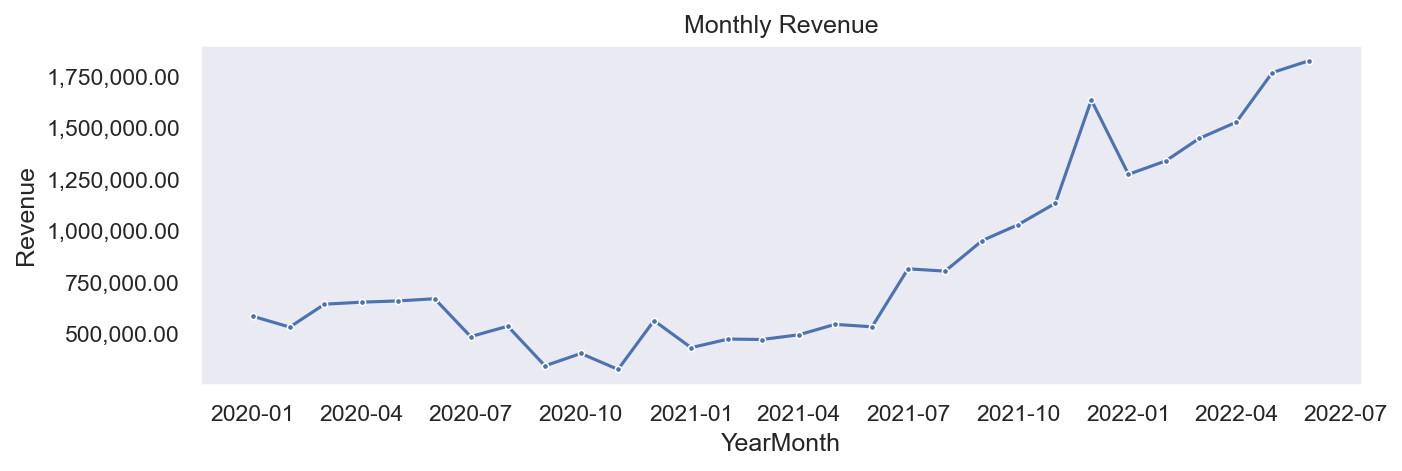

In [78]:
sns.set(style="dark")
plt.figure(figsize=(10,3))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker=".")
plt.title("Monthly Revenue")

import matplotlib.ticker as mtick

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.2f}')
)


"""plt.gca() → get current axes (the graph you just plotted)

.yaxis → access the Y-axis

.set_major_formatter(...) → control how tick labels are shown

StrMethodFormatter('{x:,.2f}') →
format each Y value:

, → thousand separator

.2f → 2 decimals"""

_____Top 10 PRODUCTS

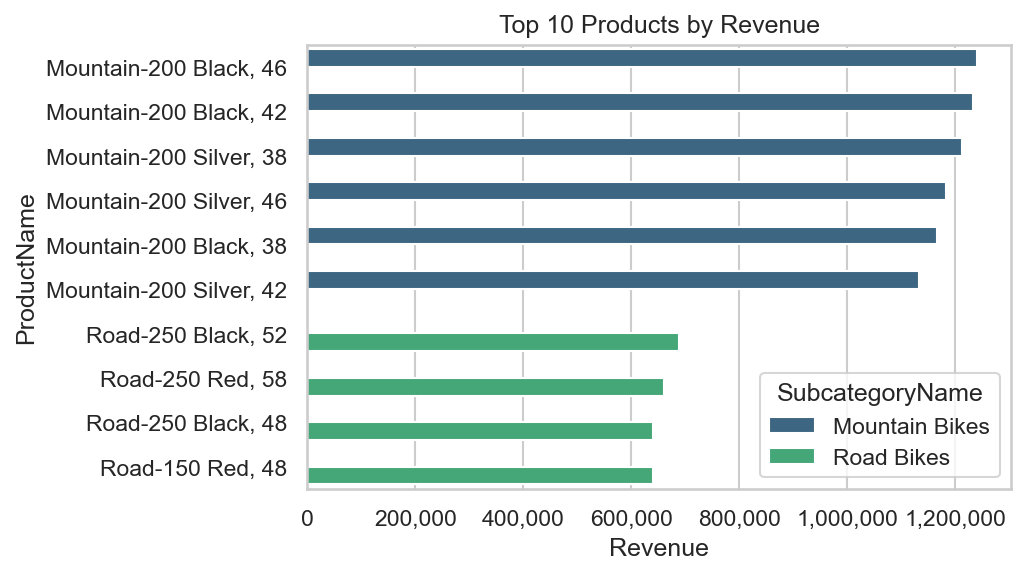

In [79]:
# Top 10 Products by Revenue
import seaborn as sns
import matplotlib.ticker as mtick

top10 = sales.groupby(['ProductKey','ProductName','SubcategoryName'], as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).head(10)
sns.set(style="whitegrid")
plt.figure(figsize=(7,4))
sns.barplot(data=top10, x='Revenue', y='ProductName',hue='SubcategoryName',palette='viridis')
plt.title("Top 10 Products by Revenue")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{int(x):,}"))
plt.tight_layout()
plt.savefig('Top 10 Products')
plt.show()


In [80]:
sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName', 'FirstName',
       'LastName', 'Gender', 'AnnualIncome', 'Revenue', 'Profit'],
      dtype='object')

____Revenue By Category

In [81]:
cat_rev = sales.groupby('CategoryName')['Revenue'].sum()
cat_rev

CategoryName
Accessories     906673.11
Bikes         23642495.10
Clothing        365418.62
Name: Revenue, dtype: float64

In [82]:
sales.groupby('CategoryName', as_index=False)['Revenue'].sum().sort_values('Revenue',ascending=False)

,CategoryName,Revenue
1,Bikes,23642495.10
0,Accessories,906673.11
2,Clothing,365418.62


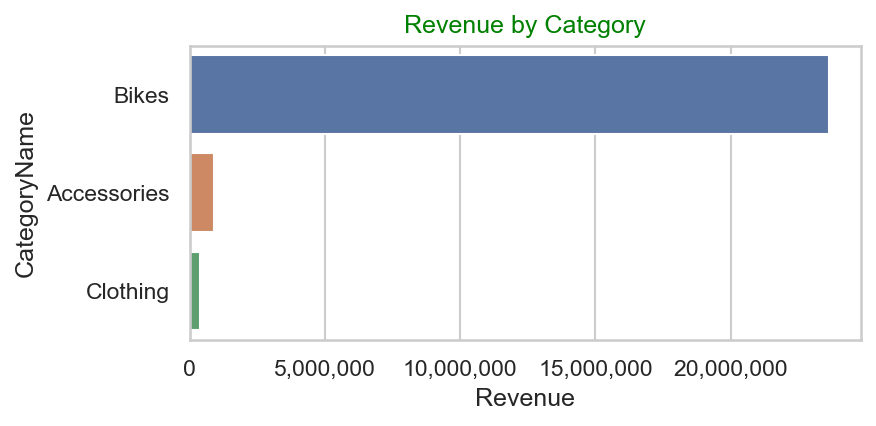

In [83]:
import seaborn as sns
import matplotlib.ticker as mtick

cat_rev = sales.groupby('CategoryName', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False)
sns.set(style="whitegrid")
plt.figure(figsize=(6,3))
sns.barplot(data=cat_rev, x='Revenue', y='CategoryName')
plt.title("Revenue by Category",color ='Green')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{int(x):,}"))
plt.tight_layout()
plt.savefig('Revenue by Category')
plt.show()


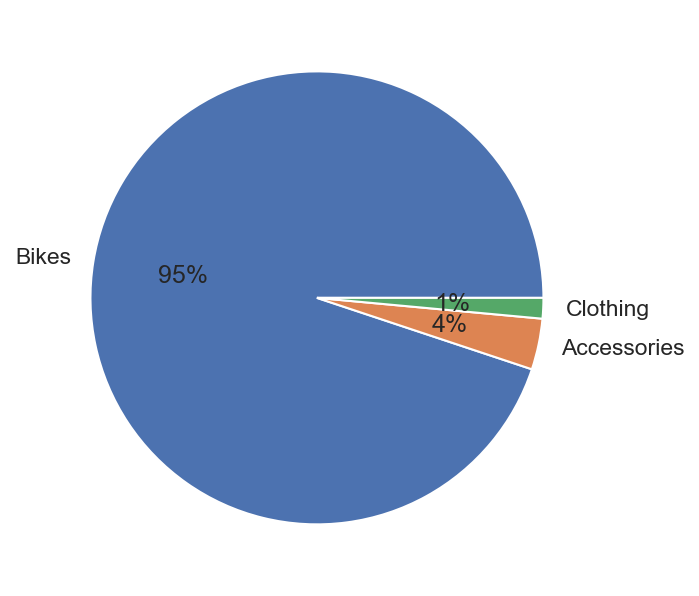

In [84]:
plt.figure(figsize=(5,5))
plt.pie(cat_rev['Revenue'], labels=cat_rev['CategoryName'], autopct='%1.0f%%')
plt.show()

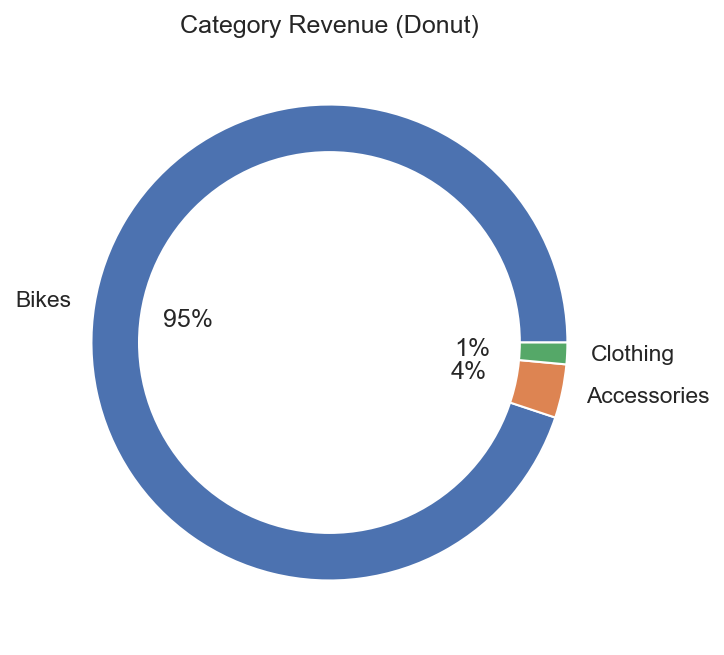

In [85]:
plt.figure(figsize=(5,10))
plt.pie(cat_rev['Revenue'], labels=cat_rev['CategoryName'], autopct='%1.0f%%')

# add a circle in middle → donut
centre = plt.Circle((0,0), 0.8, fc='white')
plt.gca().add_artist(centre)
plt.tight_layout()
plt.title("Category Revenue (Donut)")
plt.savefig('Category Revenue (Donut)s')
plt.show()

# Chart 05: Top products by Return Rate

     ProductKey  SoldQty
0           214     2099
1           215     1940
2           220     1995
3           223     4151
4           226      392
..          ...      ...
125         599       55
126         600       41
127         604      356
128         605      355
129         606      383

[130 rows x 2 columns]
     ProductKey  ReturnQty
0           214         70
1           215         52
2           220         66
3           223         46
4           226         12
..          ...        ...
119         599          1
120         600          3
121         604          7
122         605         15
123         606         11

[124 rows x 2 columns]
     ProductKey  SoldQty  ReturnQty  ReturnRate
0           214     2099      70.00        0.03
1           215     1940      52.00        0.03
2           220     1995      66.00        0.03
3           223     4151      46.00        0.01
4           226      392      12.00        0.03
..          ...      ...        ...     

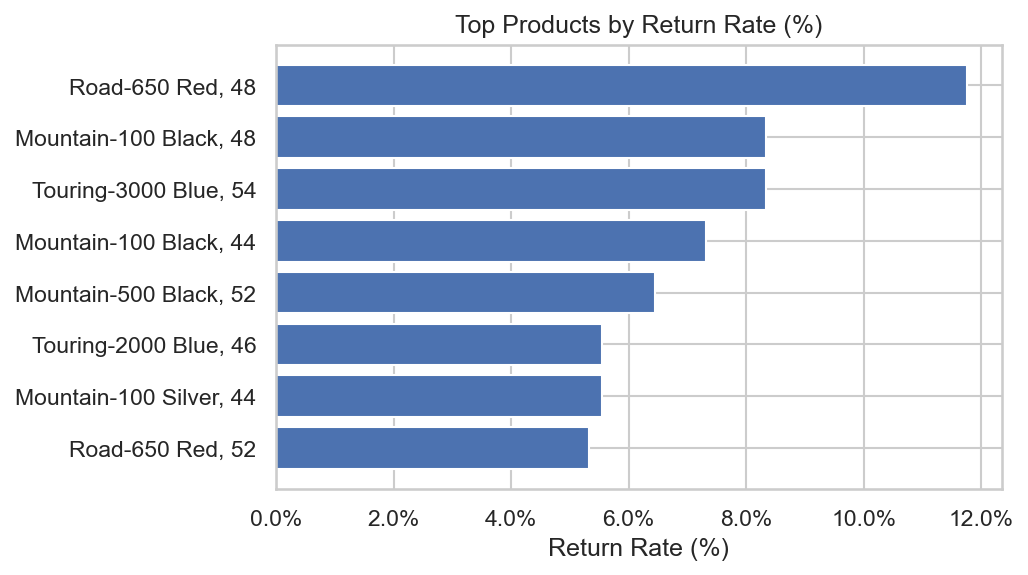

In [86]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sold = sales.groupby('ProductKey', as_index=False)['OrderQuantity'].sum().rename(columns={'OrderQuantity':'SoldQty'})
print(sold)
ret = returns.groupby('ProductKey', as_index=False)['ReturnQuantity'].sum().rename(columns={'ReturnQuantity':'ReturnQty'})
print(ret)
ret_summary = sold.merge(ret, how='left', on='ProductKey')
ret_summary['ReturnQty'] = ret_summary['ReturnQty'].fillna(0)
ret_summary['ReturnRate'] = ret_summary['ReturnQty'] / ret_summary['SoldQty']
print(ret_summary)
top_return = ret_summary[ret_summary['SoldQty']>0].sort_values('ReturnRate', ascending=False).head(8)
print(top_return)
top_return = top_return.merge(products[['ProductKey','ProductName']], on='ProductKey', how='left')
print("topreturn2",top_return)
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(top_return['ProductName'], (top_return['ReturnRate'][::-1]*100))
ax.set_title("Top Products by Return Rate (%)")
ax.set_xlabel("Return Rate (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('Top Products by Return Rate (%)')
plt.show()


 # Revenue by Territory

In [87]:
territory = pd.read_csv(r"C:\Users\pawan\OneDrive\python project\AdventureWorks Territory.csv")
territory

,SalesTerritoryKey,Region,Country,Continent
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America
3,4,Southwest,United States,North America
4,5,Southeast,United States,North America
5,6,Canada,Canada,North America
6,7,France,France,Europe
7,8,Germany,Germany,Europe
8,9,Australia,Australia,Pacific
9,10,United Kingdom,United Kingdom,Europe


In [88]:
territory['TerritoryKey'] = territory['SalesTerritoryKey']

In [89]:
sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName', 'FirstName',
       'LastName', 'Gender', 'AnnualIncome', 'Revenue', 'Profit'],
      dtype='object')

In [90]:
territory

,SalesTerritoryKey,Region,Country,Continent,TerritoryKey
0,1,Northwest,United States,North America,1
1,2,Northeast,United States,North America,2
2,3,Central,United States,North America,3
3,4,Southwest,United States,North America,4
4,5,Southeast,United States,North America,5
5,6,Canada,Canada,North America,6
6,7,France,France,Europe,7
7,8,Germany,Germany,Europe,8
8,9,Australia,Australia,Pacific,9
9,10,United Kingdom,United Kingdom,Europe,10


In [91]:
sales = sales.merge(territory[['TerritoryKey','Region','Country','Continent']],
    how = 'left',
    on  = 'TerritoryKey'
                   )

In [92]:
sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'ProductName',
       'ProductPrice', 'ProductCost', 'ProductSubcategoryKey',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName', 'FirstName',
       'LastName', 'Gender', 'AnnualIncome', 'Revenue', 'Profit', 'Region',
       'Country', 'Continent'],
      dtype='object')

           Region    Revenue
2         Central    3143.06
5       Northeast    6401.57
7       Southeast   11585.62
1          Canada 1769245.81
3          France 2362643.32
4         Germany 2524679.97
9  United Kingdom 2902562.09
6       Northwest 3095074.47
8       Southwest 4822794.70
0       Australia 7416456.20


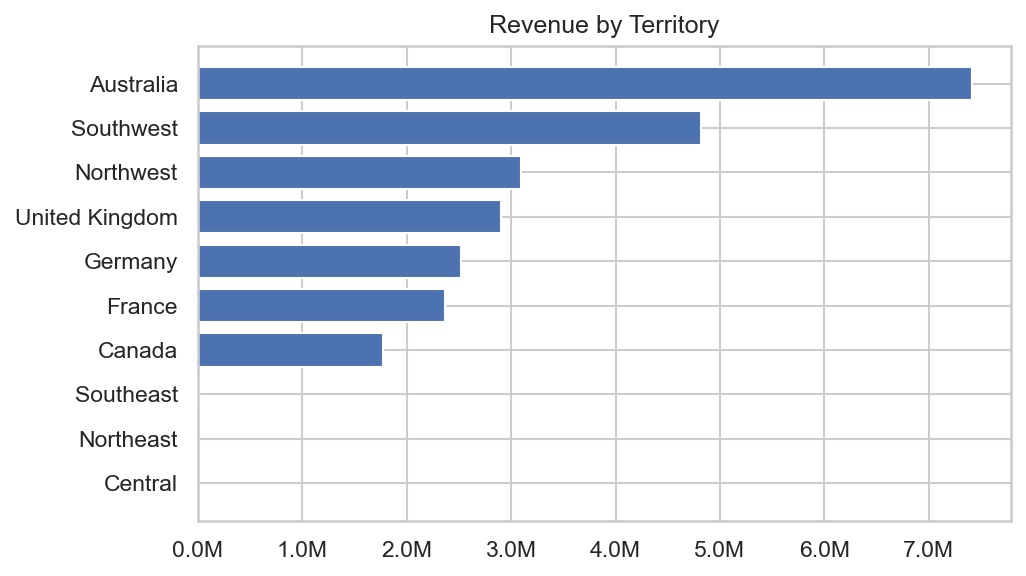

In [93]:
terr = sales.groupby('Region', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=True)
print(terr)
labels = terr['Region'].astype(str)

fig, ax = plt.subplots(figsize=(7,4))
ax.barh(labels, terr['Revenue'],0.75)
ax.set_title("Revenue by Territory")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{x/1_000_000}M"))
plt.tight_layout()
plt.savefig('Revenue by Territory')
plt.show()

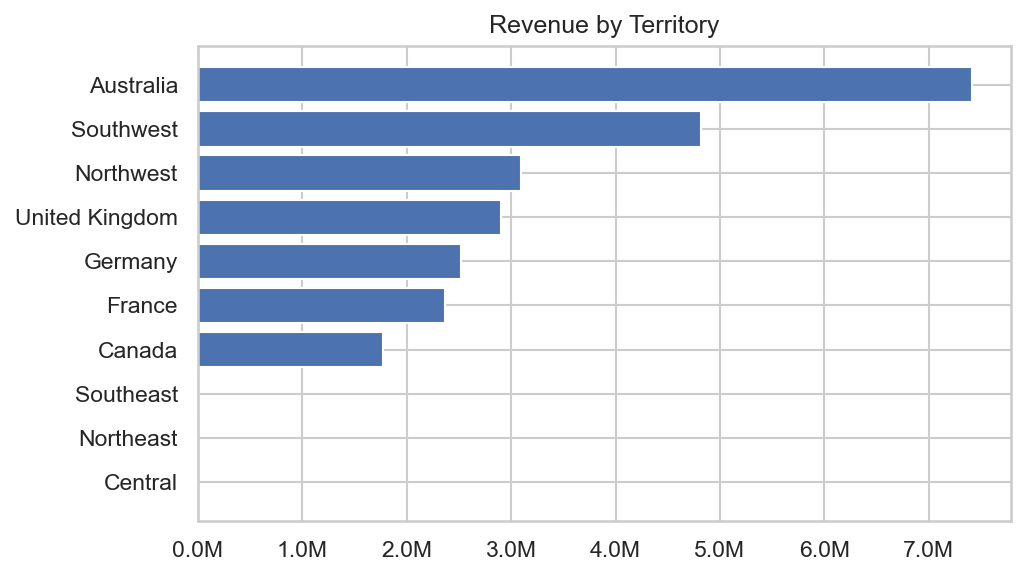

In [94]:
terr = sales.groupby('Region', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=True)
labels = terr['Region'].astype(str)

fig, ax = plt.subplots(figsize=(7,4))
ax.barh(labels, terr['Revenue'])
ax.set_title("Revenue by Territory")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{x/1_000_000}M"))
plt.tight_layout()
plt.savefig('Revenue by Territory')
plt.show()

# — Top 10 Customers by Revenue

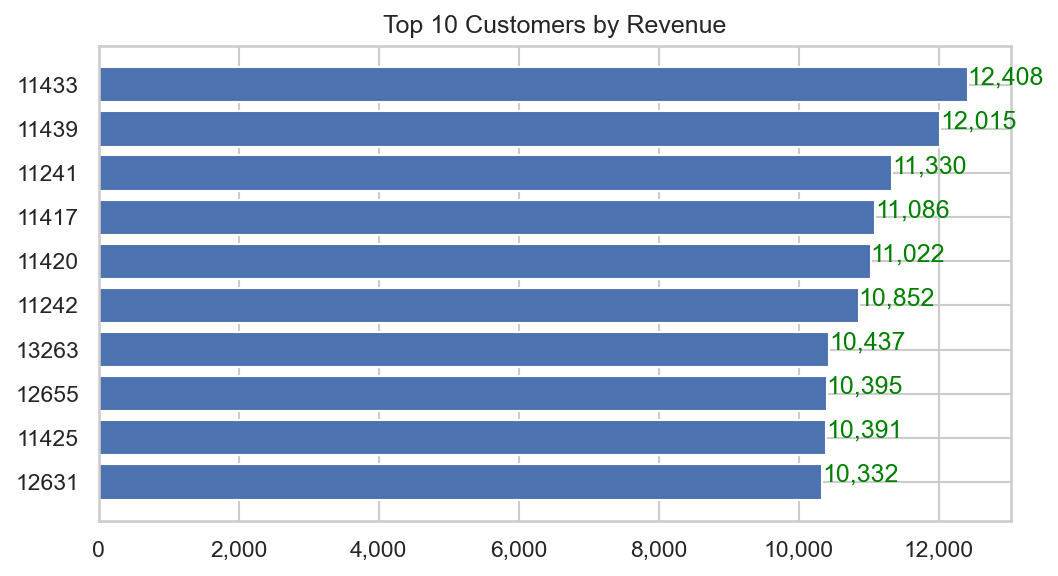

In [95]:

top_cust = sales.groupby(['CustomerKey'], as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(top_cust['CustomerKey'].astype(str)[::-1], top_cust['Revenue'][::-1])
ax.set_title("Top 10 Customers by Revenue")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{int(x):,}"))
plt.tight_layout()
for i, v in enumerate(top_cust['Revenue'][::-1]):
    ax.text(v, i, f"{v:,.0f}",color='Green')
plt.show()

# — Profit by Category

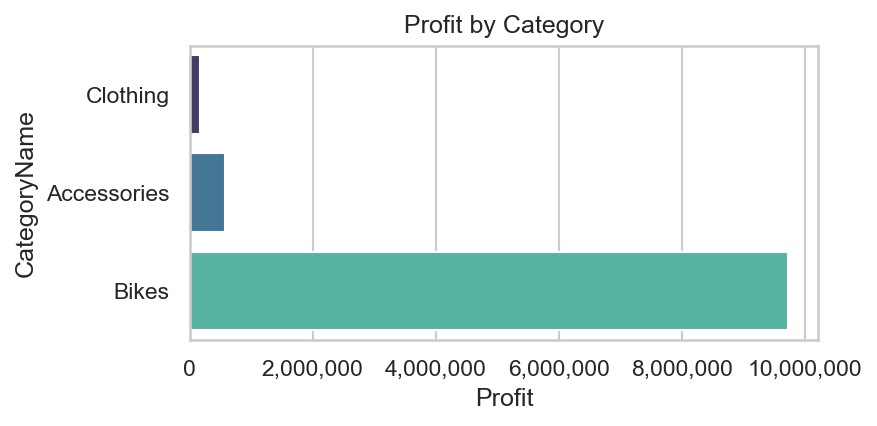

In [96]:
if 'Profit' in sales.columns:
    prof_cat = sales.groupby('CategoryName', as_index=False)['Profit'].sum().sort_values('Profit', ascending=True)
    plt.figure(figsize=(6,3))
    sns.barplot(data=prof_cat, x='Profit', y='CategoryName', palette='mako')
    plt.title("Profit by Category")
    plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{int(x):,}"))
    plt.tight_layout()
    plt.show()
else:
    print("Profit column not available.")

# — Revenue by Product Color (

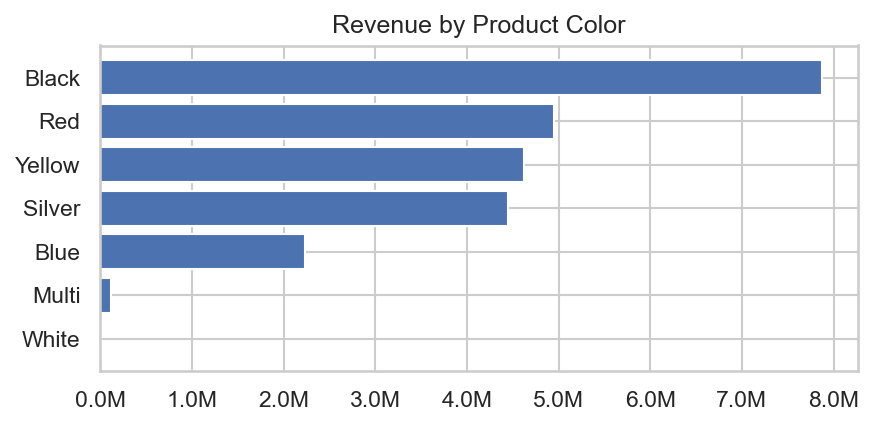

In [97]:
if 'ProductColor' in products.columns:
    color_sales = sales.merge(products[['ProductKey','ProductColor']].drop_duplicates(), on='ProductKey', how='left')
    color_rev = color_sales.groupby('ProductColor', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=True)
    fig, ax = plt.subplots(figsize=(6,3))
    ax.barh(color_rev['ProductColor'].astype(str), color_rev['Revenue'])
    ax.set_title("Revenue by Product Color")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,pos: f"{x/1_000_000:,}M"))
    plt.tight_layout()
    
    plt.show()
else:
    print("ProductColor not available in products.")